
# 22A Computational Complexity: Foundations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/01-Foundations/22A_Computational_Complexity_Foundations.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=01-Foundations/22A_Computational_Complexity_Foundations.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# --- Global Notebook Setup ---
import timeit
import warnings

import matplotlib.pyplot as plt
import numpy as np

# Apply the standard course style for all plots
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "lines.linewidth": 2,
        "lines.markersize": 6,
    }
)
%config InlineBackend.figure_format = 'retina'  # High-res plots

warnings.filterwarnings("ignore", category=FutureWarning)


## The Lens: Why Algorithm Speed Matters
As economic models become more complex—incorporating heterogeneous agents, high-dimensional state spaces, or massive datasets—the question of whether they can be solved in a reasonable amount of time becomes critical. It is not enough for an algorithm to be correct; it must also be feasible.
**Computational complexity theory** is the branch of computer science that studies the resources (primarily time and memory) required to run an algorithm. For economists, a basic understanding of complexity is essential for recognizing which problems are feasible to solve, for choosing the right algorithm for the job, and for understanding the trade-offs inherent in model design. It provides the vocabulary to explain why a model with 2 state variables runs in seconds, but adding a third makes it take hours.


**Economic question.** In *22A Computational Complexity: Foundations*, what must remain economically invariant when the computational representation changes? The economic value of this topic is not the syntax itself but the reliability of the research workflow it enables. Small implementation choices determine whether a result can be reproduced, scaled to a panel or simulation, and audited by another researcher. As you work through the examples, ask which representation makes the economic object easiest to validate and which failure modes would silently change a quantitative conclusion.

### Learning Objectives
* **Classify** algorithms by Big-O complexity (O(1), O(n), O(n log n), O(n^2), etc.).
* **Analyze** time and space complexity of common operations on Python data structures.
* **Recognize** NP-hard problems and understand why some economic models are computationally intractable.
### Prerequisites
* **Python:** Lists, dictionaries, loops, and recursion (Module 01).
* **Mathematics:** Logarithms, polynomials, and basic combinatorics.
* **Learning-path prerequisite:** [`21_Symbolic_Computation_with_SymPy.ipynb`](21_Symbolic_Computation_with_SymPy.ipynb)


> **Learning path:** Building on [`21_Symbolic_Computation_with_SymPy.ipynb`](21_Symbolic_Computation_with_SymPy.ipynb); next continue with [`22B_Complexity_in_Economic_Applications.ipynb`](22B_Complexity_in_Economic_Applications.ipynb).


### Table of Contents
1. [The Lens: Why Algorithm Speed Matters](#the-lens-why-algorithm-speed-matters)
2. [Big-O Notation: Characterizing Scalability](#big-o-notation-characterizing-scalability)
3. [Asymptotic Notation, Formally](#asymptotic-notation-formally)
4. [Complexity Classes and P vs NP](#complexity-classes-and-p-vs-np)
5. [Empirical Verification with `timeit`](#empirical-verification-with-timeit)
6. [Summary](#summary)
7. [Exercises](#exercises)


### Big-O Notation: Characterizing Scalability

**Big-O notation** is the standard way to describe an algorithm's efficiency in the worst-case scenario. It characterizes how the runtime or memory usage of an algorithm grows as the size of the input, $n$, grows. It ignores constant factors and lower-order terms, focusing on the dominant term that determines the algorithm's scalability.

**Common Complexity Classes:**
- **O(1) - Constant Time:** The runtime is independent of the input size. (e.g., accessing an element in an array by its index).
- **O(log n) - Logarithmic Time:** The runtime grows logarithmically with the input size. Extremely efficient. (e.g., binary search).
- **O(n) - Linear Time:** The runtime grows linearly with the input size. (e.g., finding the maximum value in an unsorted list).
- **O(n log n) - Log-Linear Time:** The 'gold standard' for sorting algorithms. (e.g., Merge Sort, Quicksort).
- **O(n^2) - Quadratic Time:** The runtime grows with the square of the input size. Becomes slow quickly. (e.g., nested loops, naive matrix multiplication).
- **O(2^n) - Exponential Time:** The runtime doubles with each additional element in the input. Becomes intractable for even moderately sized inputs. (e.g., traveling salesman problem via brute force).
- **O(n!) - Factorial Time:** Even worse than exponential. Unfeasible for all but the smallest inputs.


### Asymptotic Notation, Formally

The description above is the working intuition. Because complexity claims are *mathematical* claims — and because economists routinely assert that an estimator is "$O(n^2)$" or that a method is "intractable" — it is worth having the definitions precisely, along with the two siblings of Big-O that the informal account leaves out.

#### The Three Definitions

Let $f, g : \mathbb{N} \to \mathbb{R}_{\ge 0}$ be functions of the input size $n$ (say, runtime and a candidate growth rate).

> **Definition (Big-O — asymptotic upper bound).** $f(n) = O(g(n))$ if there exist constants $c > 0$ and $n_0 \in \mathbb{N}$ such that
> $$ 0 \;\le\; f(n) \;\le\; c\, g(n) \qquad \text{for all } n \ge n_0. $$

> **Definition (Big-Omega — asymptotic lower bound).** $f(n) = \Omega(g(n))$ if there exist $c > 0$ and $n_0$ such that $f(n) \ge c\, g(n)$ for all $n \ge n_0$.

> **Definition (Big-Theta — tight bound).** $f(n) = \Theta(g(n))$ if $f(n) = O(g(n))$ **and** $f(n) = \Omega(g(n))$; equivalently, there exist $c_1, c_2 > 0$ and $n_0$ with $c_1 g(n) \le f(n) \le c_2 g(n)$ for all $n \ge n_0$.

Two features of these definitions do all the work, and both are deliberate:

- **"There exist constants $c$"** — constant factors are ignored. An algorithm taking $5n$ steps and one taking $1000n$ steps are both $O(n)$. This is what makes the analysis machine-independent (a 2× faster CPU changes $c$, not the complexity class), and it is also why complexity analysis alone can mislead in practice: the $O(n \log n)$ algorithm with a huge constant may lose to the $O(n^2)$ one at every input size you actually run.
- **"For all $n \ge n_0$"** — only *eventual* behavior matters. Small-$n$ behavior is unconstrained.

#### Worked Example: Verifying a Bound from the Definition

**Claim:** $3n^2 + 100n + 7 = O(n^2)$.

*Proof.* We must produce specific $c$ and $n_0$. For all $n \ge 1$ we have $n \le n^2$ and $1 \le n^2$, so

$$ 3n^2 + 100n + 7 \;\le\; 3n^2 + 100n^2 + 7n^2 \;=\; 110\, n^2. $$

Taking $c = 110$ and $n_0 = 1$ satisfies the definition. $\blacksquare$

The same function is also $\Omega(n^2)$ (take $c = 3$, $n_0 = 1$, since $3n^2 + 100n + 7 \ge 3n^2$), and therefore $\Theta(n^2)$ — the bound is *tight*, which is the honest way to describe it.

> **⚠️ Common trap.** $3n^2 = O(n^3)$ is a perfectly **true** statement — Big-O is an upper bound, not a claim of tightness. So "this algorithm is $O(n^3)$" does not preclude it being $\Theta(n)$. When you mean tight, say $\Theta$. The literature's habit of writing "$=$" instead of "$\in$" compounds the confusion: $O(g)$ is a *set* of functions, and $f = O(g)$ properly means $f \in O(g)$ — which is why the relation is not symmetric ($O(n) = O(n^2)$ is true reading left-to-right, nonsense reading right-to-left).

#### Where the Bound Applies: Worst, Average, Best Case

Complexity classes and worst/average/best case are **orthogonal** axes, often conflated. Quicksort is a standard illustration:

| Case | Complexity | When |
|---|---|---|
| Best | $\Theta(n \log n)$ | Pivot splits the array evenly at each step |
| Average | $\Theta(n \log n)$ | Over random pivot choice / random input order |
| Worst | $\Theta(n^2)$ | Pivot is always the min or max (e.g., already-sorted input with naive pivoting) |

One can legitimately say quicksort is "$O(n^2)$" (worst case) *and* "$\Theta(n \log n)$" (average case) — these describe different questions. State which one you mean.

### Complexity Classes and P vs NP

Asymptotic notation classifies *algorithms*. Complexity theory classifies *problems* — by the best algorithm that could ever exist for them.

> **Definition (P).** The class of decision problems solvable by a deterministic algorithm in time $O(n^k)$ for some constant $k$ — **polynomial time**. Informally, "tractable."

> **Definition (NP).** The class of decision problems whose "yes" answers can be **verified** in polynomial time given a suitable certificate. (NP stands for *nondeterministic* polynomial, not "non-polynomial" — a frequent misreading.)

The distinction is between *finding* and *checking*. Given a proposed assignment of workers to tasks, checking whether total cost is below a threshold is easy; *finding* the cheapest assignment among exponentially many may not be. Note $\text{P} \subseteq \text{NP}$ by direct construction: if you can solve a problem quickly, you can verify any claimed answer quickly by re-solving the instance yourself and checking the answer matches.

> **Definition (NP-hard, NP-complete).** A problem $H$ is **NP-hard** if every problem in NP reduces to it in polynomial time — so a polynomial algorithm for $H$ would yield one for *all* of NP. If $H$ is additionally *in* NP, it is **NP-complete**: among the hardest problems in NP.

**The P vs NP question** asks whether $\text{P} = \text{NP}$ — whether every problem whose solutions are easy to check is also easy to solve. It is the central open problem of computer science and one of the Clay Millennium Prize problems. Cook (1971) and Levin independently showed Boolean satisfiability (SAT) is NP-complete, and Karp (1972) exhibited 21 more; thousands are known today. The overwhelming consensus is $\text{P} \neq \text{NP}$, but no proof exists.

$$ \text{P} \;\subseteq\; \text{NP} \;\subseteq\; \text{PSPACE} \;\subseteq\; \text{EXPTIME}, \qquad \text{with } \text{P} \subsetneq \text{EXPTIME} \text{ known (Time Hierarchy Theorem).} $$

That last containment being *strict* is the one thing we do know: some problems provably require exponential time. But where exactly the P/NP boundary falls inside that chain remains open.

#### Why Economists Should Care

This is not a detour into computer science trivia. Several load-bearing problems in economics are NP-hard, with three distinct consequences:

| Economic problem | Complexity status | Implication |
|---|---|---|
| **Combinatorial auctions** (winner determination with package bids) | NP-hard | The FCC spectrum auctions must use approximation algorithms or restricted bidding languages — the mechanism design is shaped by the computational limit |
| **Computing Nash equilibria** (2-player, general-sum) | PPAD-complete (Daskalakis, Goldberg & Papadimitriou 2009) | If a "solution concept" cannot be computed efficiently, can we defend it as a prediction of what boundedly-rational agents actually do? |
| **Integer/combinatorial matching** (some many-to-many variants) | NP-hard | Kidney exchange and school-choice mechanisms are designed around what is computable |
| **Optimal taxation over discrete types**, **MIP-based structural estimation** | NP-hard in general | Estimation routines rely on relaxations, heuristics, or problem structure — with no guarantee of the global optimum |

The deepest implication is conceptual. Classical economic theory routinely assumes agents solve optimization problems *instantly and exactly*. If the problem is NP-hard, no agent — human, firm, or supercomputer — can be doing that in general. This is the formal backbone of **bounded rationality**: computational complexity supplies a principled, non-arbitrary reason why real agents use heuristics, and hence a discipline on which models of "rational" behavior are even coherent.

**A note on the curse of dimensionality.** The dynamic-programming methods in Module 03 face a related but distinct problem: a state space with $d$ dimensions discretized into $m$ points per dimension has $m^d$ states. That is exponential in $d$ — not NP-hardness (the problem is polynomial in the *number of states*), but equally fatal in practice. This is precisely why the course later turns to function approximation, sparse grids, and neural-network-based methods: they trade exactness for an escape from $m^d$.


#### Advanced Topic: Mathematical Derivation of Complexity

Why is a nested loop $O(n^2)$? We can derive this by counting the operations.

Consider this code:
```python
total = 0
for i in range(n):
    for j in range(n):
        total += i * j
```

The inner operation (`total += i * j`) happens once for every pair of $(i, j)$.

$$ \text{Total Ops} = \sum_{i=0}^{n-1} \sum_{j=0}^{n-1} 1 = \sum_{i=0}^{n-1} n = n \times n = n^2 $$

This mathematical counting confirms that the runtime scales quadratically with $n$.


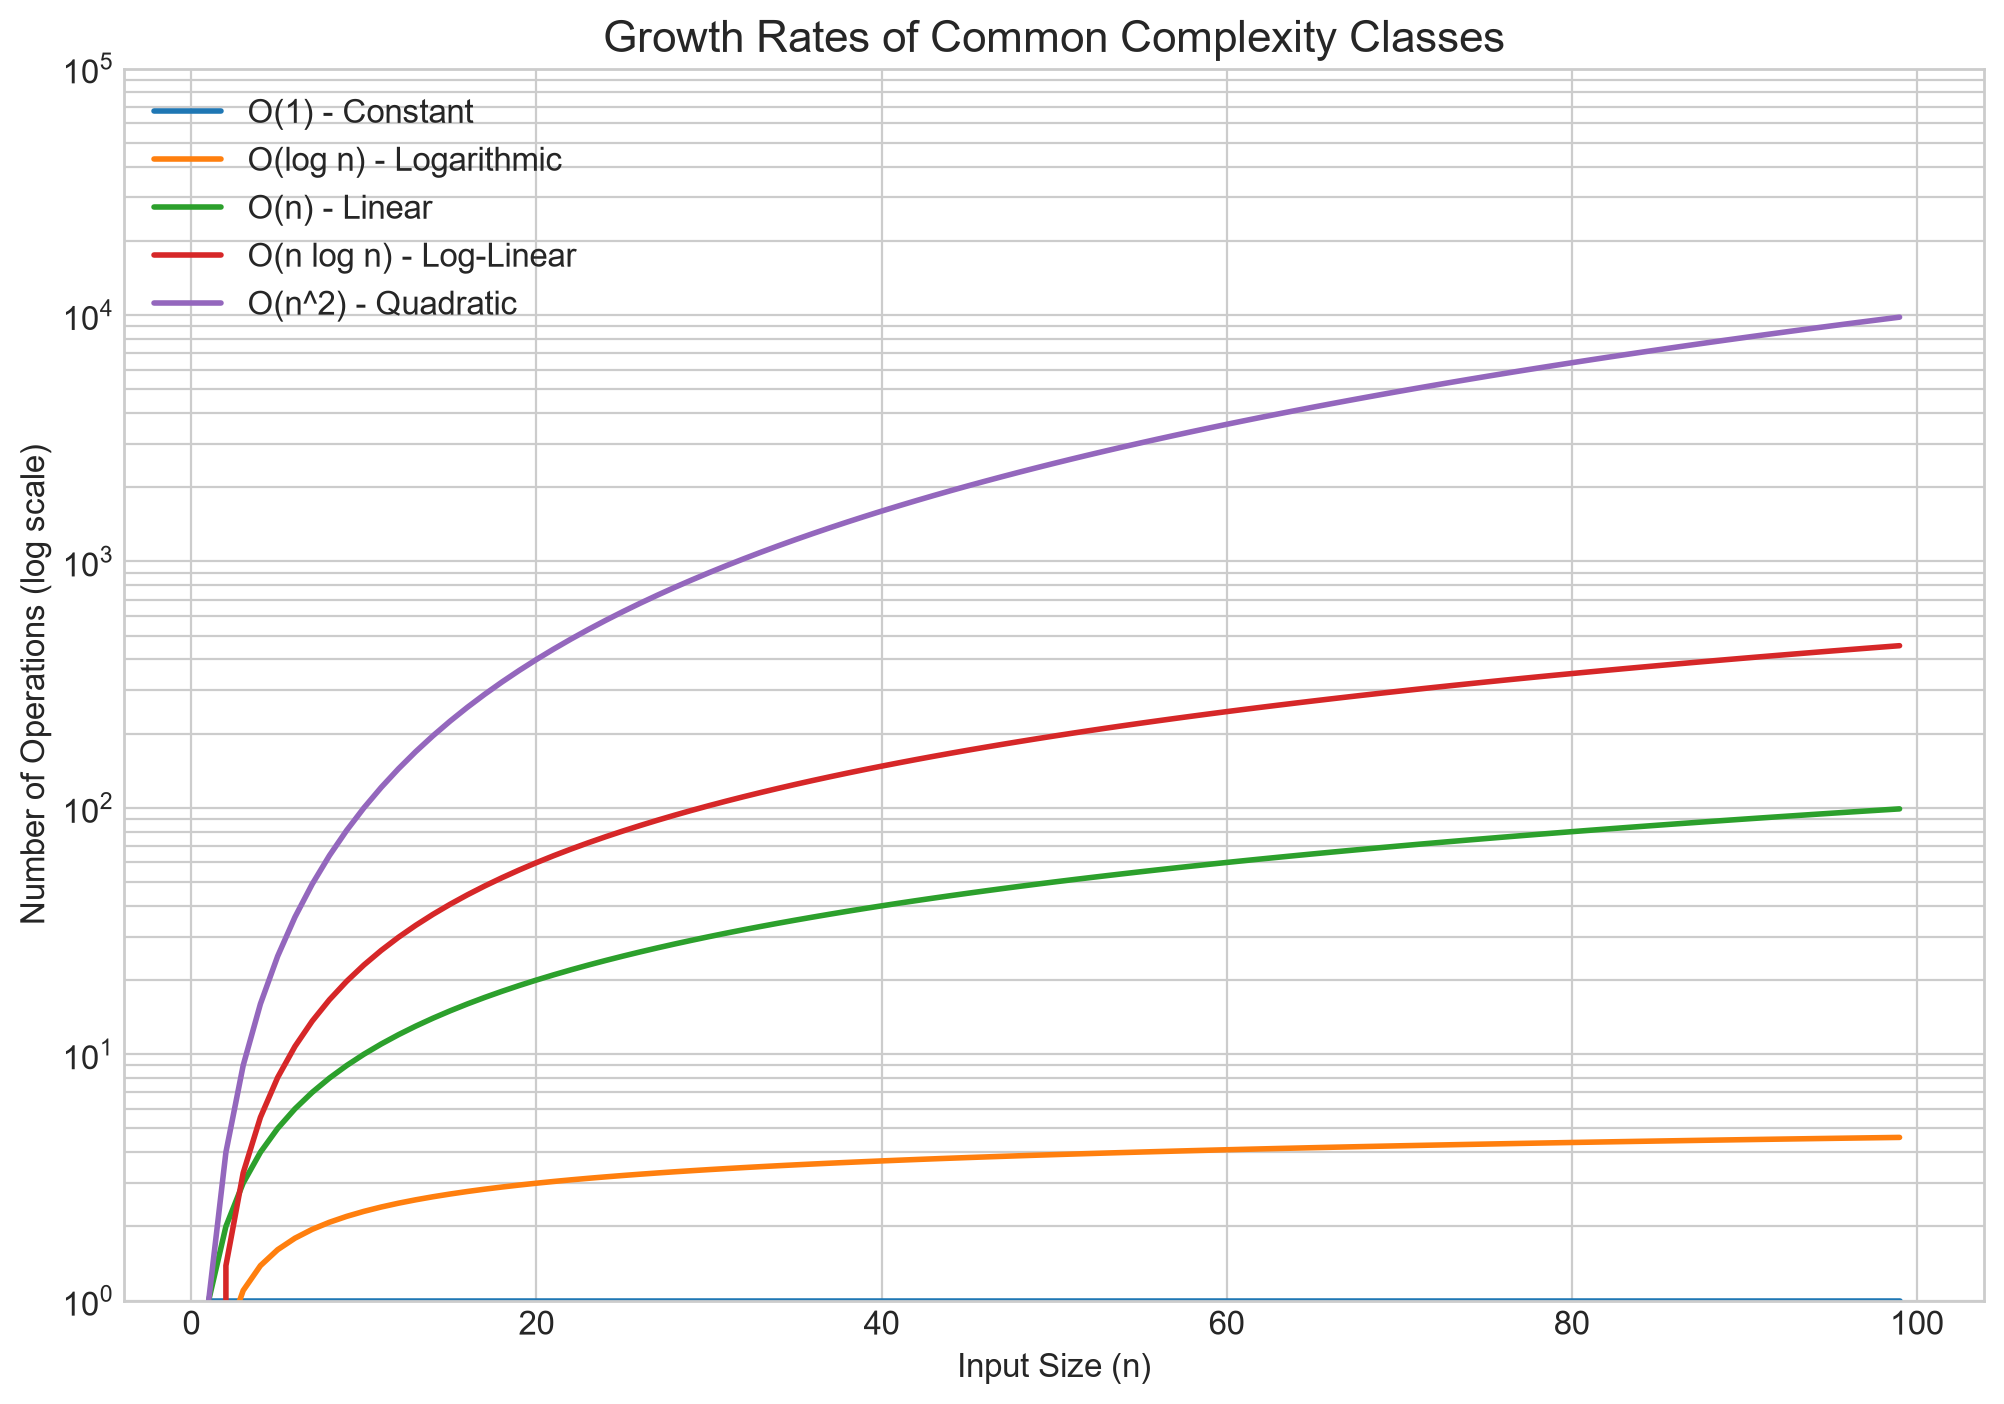

In [2]:
n = np.arange(1, 100)
plt.figure(figsize=(12, 8))
plt.plot(n, np.ones_like(n), label="O(1) - Constant")
plt.plot(n, np.log(n), label="O(log n) - Logarithmic")
plt.plot(n, n, label="O(n) - Linear")
plt.plot(n, n * np.log(n), label="O(n log n) - Log-Linear")
plt.plot(n, n**2, label="O(n^2) - Quadratic")
plt.title("Growth Rates of Common Complexity Classes")
plt.xlabel("Input Size (n)")
plt.ylabel("Number of Operations (log scale)")
plt.yscale("log")
plt.legend()
plt.ylim(1, 10**5)
plt.grid(True, which="both", ls="-")
plt.show()


#### Grid Search Scaling
A common task is searching for optimal parameters over a grid. If we have $D$ parameters and test $N$ values for each, the total number of evaluations is $N^D$. This is exponential complexity $O(N^D)$.

For example, estimating a model with 5 parameters using a grid of 20 values each requires $20^5 = 3,200,000$ evaluations. If each evaluation takes 0.1 seconds, the total time is over 3 days. This motivates the use of more efficient optimization algorithms (like Nelder-Mead or BFGS) which are closer to polynomial time.


### Empirical Verification with `timeit`

We can empirically verify the complexity of algorithms using Python's `timeit` module. Let's compare finding an item in a list (O(n)) vs. a set (O(1)).


Size 1000: List=0.00048s, Set=0.00000s
Size 10000: List=0.00517s, Set=0.00001s
Size 100000: List=0.05323s, Set=0.00000s


Size 1000000: List=0.56503s, Set=0.00000s


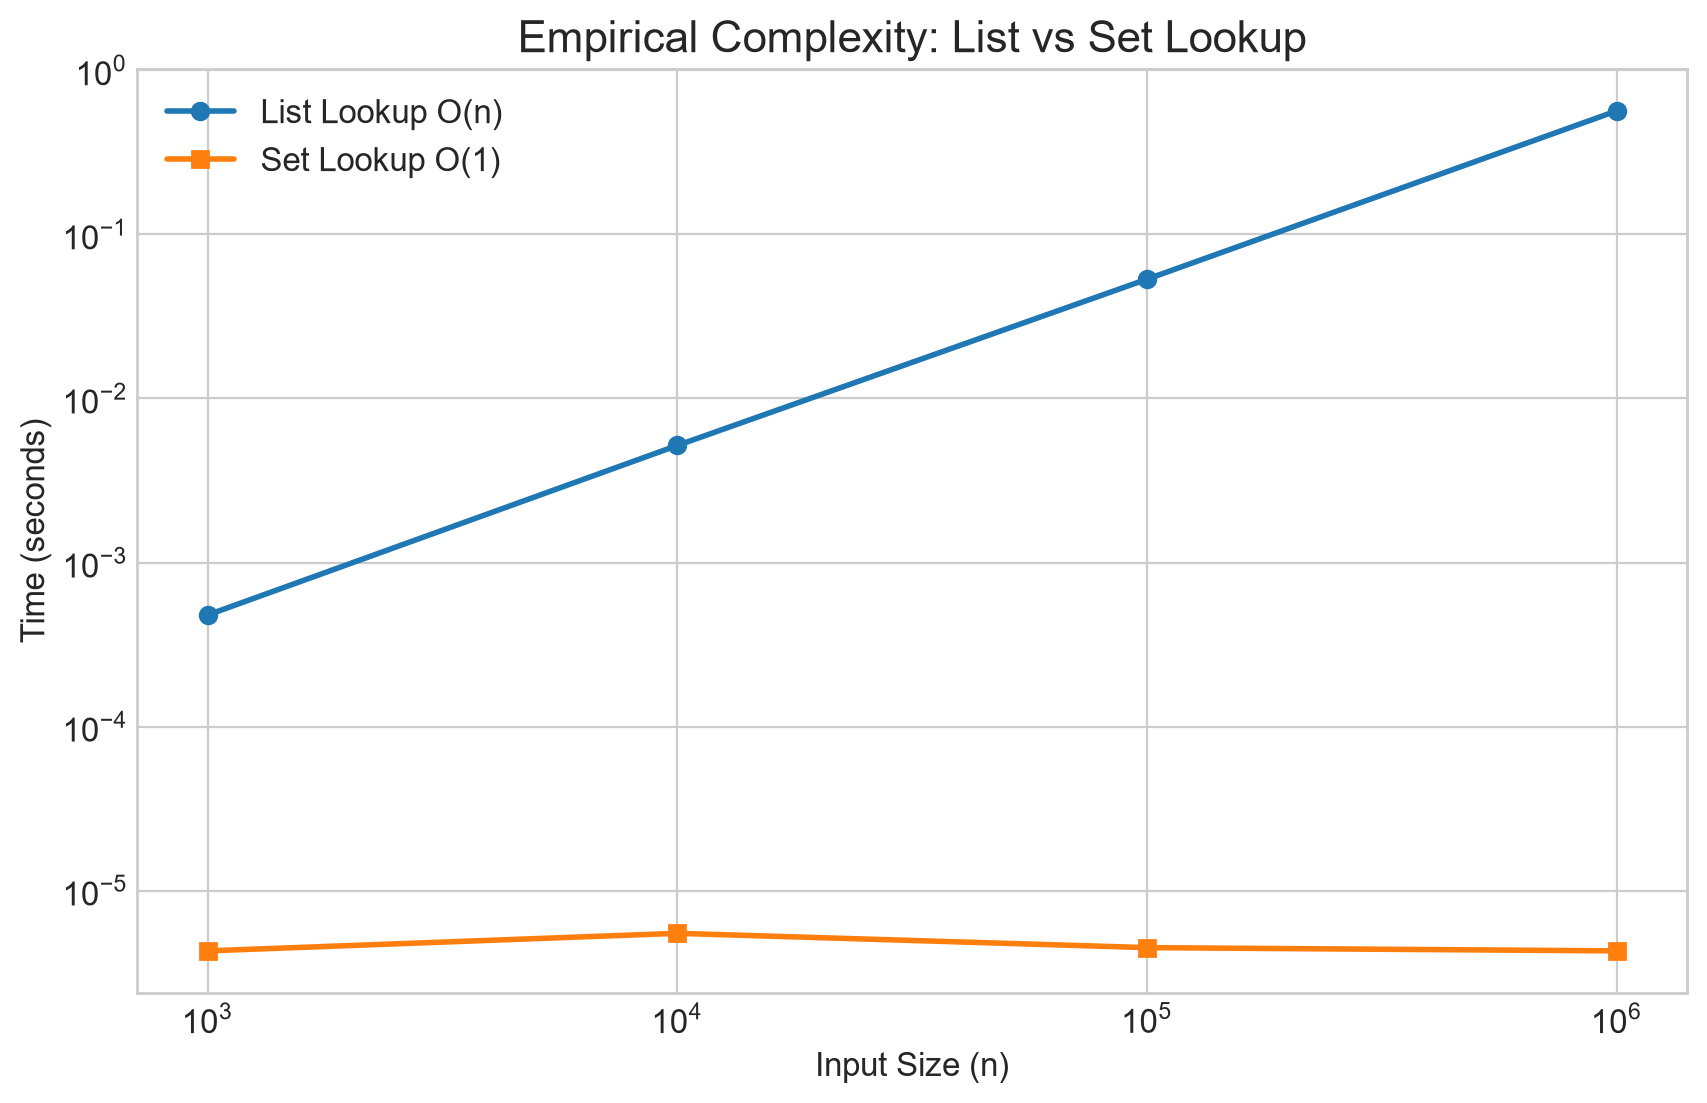

In [3]:
sizes = [1000, 10000, 100000, 1000000]
list_times = []
set_times = []

for size in sizes:
    # Generate data
    data_list = list(range(size))
    data_set = set(data_list)

    # Test Case: Find the last element (Worst case for list)
    target = size - 1

    # Time List lookup
    t_list = timeit.timeit(lambda: target in data_list, number=100)
    list_times.append(t_list)

    # Time Set lookup
    t_set = timeit.timeit(lambda: target in data_set, number=100)
    set_times.append(t_set)

    print(f"Size {size}: List={t_list:.5f}s, Set={t_set:.5f}s")

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(sizes, list_times, "o-", label="List Lookup O(n)")
plt.plot(sizes, set_times, "s-", label="Set Lookup O(1)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size (n)")
plt.ylabel("Time (seconds)")
plt.title("Empirical Complexity: List vs Set Lookup")
plt.legend()
plt.show()


### Three-Tier Practice Ladder

**1. Mechanism and assumptions (Conceptual):** Explain the central computational idea in **22A Computational Complexity: Foundations** and connect it to one explicit economic object or research workflow.

**2. Reproduce and diagnose (Applied):** Reproduce an example involving Big-O Notation: Characterizing Scalability, Asymptotic Notation, Formally, then change one input and explain the result before running the code.

**3. Robust extension (Challenge):** Extend the example to a larger or less convenient case and document the correctness and performance checks needed before trusting the result.

**3b. Failure analysis (Challenge):** A student defends an $O(n^2)$ matcher because 'n is small', yet profiling at realistic $n$ shows it consuming 90% of runtime. Diagnose the scaling misjudgment by timing at several $n$ and fitting the growth curve, replace with the $O(n \log n)$ approach, and report measured versus theoretical exponents.

> Use the existing exercises above when they target the same skill; this ladder makes the intended progression explicit rather than replacing instructor-authored problems.


# Summary

This part established the language of computational complexity and how to measure scalability with Big-O notation, backed by empirical timing evidence.


### Exercises

1. **Big-O classification:** Identify the complexity of common Python operations on lists and dictionaries.
2. **Timing comparison:** Use `timeit` to compare lookup times between lists and sets for different sizes.


## References & Further Reading

- Python Software Foundation. *Python 3 Documentation*.
- Harris, C. R. et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362.
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly.
